In [1]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
import json 
from shapely import wkt 
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose

import glob
import os
import csv
import ast

from math import sqrt
import calplot
from pathlib import Path

In [3]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)

In [4]:
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import warnings

warnings.filterwarnings(
    "ignore",
    message="This figure includes Axes that are not compatible with tight_layout"
)

### Reading Temp & Precip  (using 6km buffer version) 

In [5]:
temp_all = pd.read_csv(DATA_DIR / 'processed_weather_data/temp_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
temp_all['time'] = pd.to_datetime(temp_all['time'])

precip_all = pd.read_csv(DATA_DIR / 'processed_weather_data/precip_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
precip_all['time'] = pd.to_datetime(precip_all['time'])

### Wind (6km) 

In [6]:
hourly_wind_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_wind_avg_6km.csv').drop(columns=['Unnamed: 0'])

hourly_wind_df['Timestamp'] = pd.to_datetime(hourly_wind_df['Timestamp'])
hourly_wind_df = hourly_wind_df.rename(columns = {'Timestamp':'time'})
hourly_wind_df['Date'] = hourly_wind_df['time'].dt.date

### Lightning (6km aligned) 

In [7]:
hourly_lightning_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_lightning_avg_6km_buffer_aligned.csv').drop(columns=['Unnamed: 0'])
hourly_lightning_df['Timestamp'] = pd.to_datetime(hourly_lightning_df['Timestamp'])
hourly_lightning_df = hourly_lightning_df.rename(columns = {'Timestamp':'time'})
hourly_lightning_df['Date'] = hourly_lightning_df['time'].dt.date

### Extreme Definitions 

### Temp 

In [8]:
temp_all['Date'] = temp_all['time'].dt.floor('D')

# Hot hour flag
temp_all['Hot_Hour'] = temp_all['Temp'] > 32

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours = (
    temp_all.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours = daily_hot_hours.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

### Precip 

In [9]:
precip_all['Date'] = precip_all['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip = (
    precip_all.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

### Wind 

In [10]:
# Windy hour flag
hourly_wind_df['Windy_Hour'] = hourly_wind_df['Wind Gusts (m/s)'] > 5.93

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours = (
    hourly_wind_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours = daily_windy_hours.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

### Lightning 

In [11]:
daily_lightning_per_ea = hourly_lightning_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

## Percentiles 

In [12]:
### 90th ### 
hot_hrs_90_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.90)
temp_90_thresh = temp_all['Temp'].quantile(0.90)

precip_90_thresh = daily_precip['Precip'].quantile(0.90)
lightning_90_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.90)

windy_hrs_90_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.90)
wind_90_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.90)


### 95th ### 
hot_hrs_95_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.95)
temp_95_thresh = temp_all['Temp'].quantile(0.95)

precip_95_thresh = daily_precip['Precip'].quantile(0.95)
lightning_95_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.95)

windy_hrs_95_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.95)
wind_95_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.95)


### 99th ### 
hot_hrs_99_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.99)
temp_99_thresh = temp_all['Temp'].quantile(0.99)

precip_99_thresh = daily_precip['Precip'].quantile(0.99)
lightning_99_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.99)

windy_hrs_99_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.99)
wind_99_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.99)

#### Dictionary for percentiles 

In [13]:
# Percentile Threshold dictionaries 
temp_thresh_dict = {
    '90': temp_90_thresh,
    '95': temp_95_thresh,
    '99': temp_99_thresh
}

hot_hrs_thresh_dict = {
    '90': hot_hrs_90_thresh,
    '95': hot_hrs_95_thresh,
    '99': hot_hrs_99_thresh
}

precip_thresh_dict = {
    '90': precip_90_thresh,
    '95': precip_95_thresh,
    '99': precip_99_thresh
}

wind_thresh_dict = {
    '90': wind_90_thresh,
    '95': wind_95_thresh,
    '99': wind_99_thresh
}

windy_hrs_thresh_dict = {
    '90': windy_hrs_90_thresh,
    '95': windy_hrs_95_thresh,
    '99': windy_hrs_99_thresh
}

lightning_thresh_dict = {
    '90': 1,   # at least 1 lightning strike 
    '95': lightning_95_thresh,
    '99': lightning_99_thresh
}

## Functions 

In [14]:
## Specify Outage Duration (to be classified as outage or not) 

In [15]:
def flag_outage_hours(df, threshold):
    
    df = df.copy()
    df['Outage_Flag'] = df['outage_mins'] >= threshold
    df['Outage_Dur'] = round( (threshold/60), 2)
    df = df[['time', 'site_id', 'Outage_Flag', 'Outage_Dur']]
    
    return df

In [16]:
def prepare_hourly_df_TPLW_n_outage_data(ea_row, temp_df, precip_df, lightning_df, wind_df, pqr_df, outage_threshold):
    ea = ea_row['ea_code9ch']
    site_list = ea_row['Intersecting_Sites']

    all_merged = []

    for site_id in site_list:
        site_id = int(site_id)

        # Filter temperature
        temp_filt = (
            temp_df[temp_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        if 'Hot_Hour' in temp_filt.columns:
            temp_filt = temp_filt.drop(columns=['Hot_Hour'])

        temp_filt['time'] = temp_filt['time'].astype('datetime64[ns]')

        # Filter precipitation
        precip_filt = (
            precip_df[precip_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        precip_filt['time'] = precip_filt['time'].astype('datetime64[ns]')
        precip_filt = precip_filt[['time', 'Precip']]

        # Merge temp and precip
        merged = temp_filt.merge(precip_filt, on='time', how='outer')

        # Filter lightning and outer join
        lightning_filt = (
            lightning_df[lightning_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Lightning Events']]
        )
        merged = merged.merge(lightning_filt, on='time', how='outer')
        merged['Lightning Events'] = merged['Lightning Events'].fillna(0)

        ## Merge with Wind (inner merge) 
        wind_filt = (
            wind_df[wind_df['ea_code9ch'] == ea]
            .reset_index(drop=True)
            .drop(columns=['geometry'], errors='ignore')
        )
        wind_filt = wind_filt[['time', 'Wind Gusts (m/s)']]  
        wind_filt['time'] = wind_filt['time'].astype('datetime64[ns]')

        # Merge temp and precip
        merged = merged.merge(wind_filt, on='time', how='inner')
     
        # Filter outage data and flag
        pqr_filt = (
            pqr_df[pqr_df['site_id'] == site_id]
            .reset_index(drop=True)[['time', 'site_id', 'outage_events', 'outage_mins']]
        )
        flagged_outages = flag_outage_hours(pqr_filt, threshold=outage_threshold)

        # Inner join outages
        merged = merged.merge(flagged_outages, on='time', how='inner')

        # Add identifiers
        merged['ea_code9ch'] = ea
        merged['site_id'] = site_id

        # Reorder columns
        merged = merged[['time', 'Date', 'ea_code9ch', 'site_id', 'Temp', 'Precip', 
                 'Lightning Events', 'Wind Gusts (m/s)', 
                 'Outage_Flag', 'Outage_Dur']]

        all_merged.append(merged)

    return pd.concat(all_merged, ignore_index=True)

In [17]:
def create_daily_summary_extreme_weather_REV(
    df,
    temp_thresh,
    hot_hours_thresh,
    precip_thresh,
    lightning_thresh,
    wind_thresh,
    windy_hours_thresh
):
    df = df.copy()
    df['Date'] = df['time'].dt.date
    df['Hot_hour'] = df['Temp'] > temp_thresh
    df['Windy_Hour'] = df['Wind Gusts (m/s)'] > wind_thresh

    # Aggregate to daily summary per enumeration area
    daily_summary = (
        df.groupby(['Date', 'ea_code9ch'], as_index=False)
          .agg({
              'Precip': 'sum',
              'Lightning Events': 'sum',
              'Hot_hour': 'sum',
              'Windy_Hour': 'sum'
          })
    )

    # Classify each day by condition
    daily_summary['T'] = daily_summary['Hot_hour'] >= hot_hours_thresh
    daily_summary['W'] = daily_summary['Windy_Hour'] >= windy_hours_thresh
    daily_summary['P'] = daily_summary['Precip'] >= precip_thresh
    daily_summary['L'] = daily_summary['Lightning Events'] >= lightning_thresh

    # Add Month and Year-Month columns
    daily_summary['Month'] = pd.to_datetime(daily_summary['Date']).dt.month
    daily_summary['Year_Month'] = pd.to_datetime(daily_summary['Date']).dt.to_period('M').astype(str)

    # --- Specific combinations ---
    daily_summary['TP'] = daily_summary['T'] & daily_summary['P'] 
    daily_summary['TW'] = daily_summary['T'] & daily_summary['W'] 
    daily_summary['TL'] = daily_summary['T'] & daily_summary['L'] 
    daily_summary['PW'] = daily_summary['P'] & daily_summary['W'] 
    daily_summary['PL'] = daily_summary['P'] & daily_summary['L'] 
    daily_summary['WL'] = daily_summary['W'] & daily_summary['L'] 
    daily_summary['PWL'] = daily_summary['P'] & daily_summary['W'] & daily_summary['L'] 

    # --- Print frequency of combinations in days ---
    # print("")
    # print("")
    # combination_cols = ['T', 'P', 'W', 'L', 'TP', 'TW', 'TL', 'PW', 'PL', 'WL', 'PWL']
    # print("\nFrequency of extreme weather combinations (EA-days):")
    # print(daily_summary[combination_cols].sum().sort_values(ascending=False))
    # print("")
    # print("")

    return daily_summary

## --- Extreme Weather per Month Workflow --- 

### EA Names mapped  

In [18]:
ea_names_mapped = pd.read_csv(DATA_DIR / 'miscellaneous/ea_names_mapped.csv')

ea_names_mapped = ea_names_mapped[['ea_code9ch', 'LOC_NAME', 'BASE_NAM', 'geometry']]

### EAs n Sites - *** using new 'EAs_n_Sites' (6km) 

In [19]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

In [20]:
# merged_eas_sites['ea_code9ch'].nunique()

In [21]:
filtered_eas_sites_copy = merged_eas_sites

## Outage Workflow 

In [22]:
## 22 
pqr_hourly_22 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_22_NEW.csv')
pqr_hourly_22['time'] = pd.to_datetime(pqr_hourly_22['time'])
pqr_hourly_22['time'] = pqr_hourly_22['time'].dt.tz_convert(None)

## 23 
pqr_hourly_23 = pd.read_csv(DATA_DIR / 'miscellaneous/merged_outage_n_voltage_hourly_23_NEW.csv')
pqr_hourly_23['time'] = pd.to_datetime(pqr_hourly_23['time'])
pqr_hourly_23['time'] = pqr_hourly_23['time'].dt.tz_convert(None)

pqr_hourly_all = pd.concat([pqr_hourly_22, pqr_hourly_23], ignore_index=True).drop(columns=['Unnamed: 0'])

In [23]:
pqr_hourly_all['site_id'].nunique()

366

## Remove sites with > `10%` missing data & less than 24 months 

In [24]:
sites_to_omit = pd.read_csv(DATA_DIR / 'miscellaneous/complete_site_removal_df.csv')['site_id'].to_list()

pqr_hourly_all_rev = pqr_hourly_all[ ~( pqr_hourly_all['site_id'].isin(sites_to_omit) ) ].reset_index(drop=True)

### Global Workflow - Outages 

In [25]:
filtered_eas_sites_copy_r1 = filtered_eas_sites_copy.copy()

### ***TPLW Dataset***  (Extreme Weather per Month) 

### 95th percentile 

In [26]:
## Outage Duration & Percentile 
dur = 60  # duration in minutes --> doesn't matter here, just focused on the weather variables 
percentile = '95'

# Main loop
results = []

for _, row in filtered_eas_sites_copy_r1.iterrows():
    merged_hourly = prepare_hourly_df_TPLW_n_outage_data(
        row, 
        temp_all, 
        precip_all, 
        hourly_lightning_df, 
        hourly_wind_df, 
        pqr_hourly_all_rev, 
        outage_threshold=dur
    )
    if merged_hourly is not None:
        results.append(merged_hourly)

merged_hourly_data_global = pd.concat(results, ignore_index=True)

In [27]:
hourly_weather = merged_hourly_data_global.drop(columns=['Outage_Flag', 'Outage_Dur', 'site_id'])

In [28]:
hourly_weather['ea_code9ch'].nunique()

214

### Save the TPLW EAs to file 

In [29]:
unique_ea_codes = hourly_weather['ea_code9ch'].unique().tolist()

ea_codes_df = pd.DataFrame(unique_ea_codes, columns=['ea_code9ch'])

In [30]:
# ea_codes_df.to_csv(DATA_DIR / 'miscellaneous/unique_ea_codes_TPLW.csv', index=False)

### Summarize Extreme Weather frequency per day 

In [31]:
daily_extreme_weather_REV = create_daily_summary_extreme_weather_REV(
    hourly_weather, 
    temp_thresh = temp_thresh_dict[percentile], 
    hot_hours_thresh = hot_hrs_thresh_dict[percentile], 
    precip_thresh = precip_thresh_dict[percentile], 
    lightning_thresh = lightning_thresh_dict[percentile],  
    wind_thresh = wind_thresh_dict[percentile], 
    windy_hours_thresh = windy_hrs_thresh_dict[percentile]
)

In [32]:
daily_extreme_weather_REV = daily_extreme_weather_REV[[
            'Date', 'ea_code9ch', 
            'Precip', 'Lightning Events', 'Hot_hour', 'Windy_Hour', 
            'T', 'W', 'P', 'L', 
            'PW', 'PL', 'WL', 'PWL', 
            'Month', 'Year_Month']]

daily_extreme_weather_REV['Date'] = pd.to_datetime(daily_extreme_weather_REV['Date'])

In [33]:
daily_extreme_weather_REV.head()

,Date,ea_code9ch,Precip,Lightning Events,Hot_hour,Windy_Hour,T,W,P,L,PW,PL,WL,PWL,Month,Year_Month
0,2022-01-01,30200002,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
1,2022-01-01,30200012,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
2,2022-01-01,30200013,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
3,2022-01-01,30200014,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01
4,2022-01-01,30200015,0.0,0.0,0,0,False,False,False,False,False,False,False,False,1,2022-01


### *** DAILY version: `Proportion` of EAs per Weather Event    

In [34]:
event_cols = ['T', 'P', 'W', 'L', 'PW', 'PL', 'WL', 'PWL']

daily_event_pct = (
    daily_extreme_weather_REV
    .groupby('Date')[event_cols]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={
        col: f'{col}_pct_nonzero'
        for col in event_cols
    })
    .round(2)
)

### Day version - total event days / total EA-days 

In [35]:
import pandas as pd

def normalize_daily_extremes_by_eas(
    df,
    date_col="Date",
    num_ea=214,
    return_percent=False
):
    out = df.copy()

    # Ensure datetime
    out[date_col] = pd.to_datetime(out[date_col])

    # Columns to normalize
    value_cols = [
        c for c in out.columns
        if c != date_col
    ]

    # Normalize by total possible EAs
    out[value_cols] = out[value_cols].div(num_ea)

    # Convert to %
    if return_percent:
        out[value_cols] *= 100

    return out

In [36]:
event_cols = ['T', 'P', 'W', 'L', 'PW', 'PL', 'WL', 'PWL']

# Total event occurrence per Year-Month
day_total_all_eas = (
    daily_extreme_weather_REV
    .groupby('Date', as_index=False)[event_cols]
    .sum()
)

day_total_all_eas_norm = normalize_daily_extremes_by_eas(
    day_total_all_eas,
    date_col='Date',
    num_ea=214,
    return_percent=True
).round(2)

In [37]:
day_total_all_eas_norm.head()

,Date,T,P,W,L,PW,PL,WL,PWL
0,2022-01-01,0.47,0.00,0.0,0.00,0.0,0.0,0.0,0.0
1,2022-01-02,0.00,3.74,0.0,0.00,0.0,0.0,0.0,0.0
2,2022-01-03,4.67,0.00,0.0,0.47,0.0,0.0,0.0,0.0
3,2022-01-04,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0
4,2022-01-05,0.93,0.00,0.0,0.00,0.0,0.0,0.0,0.0


## Calendar Plots  

In [38]:
def plot_extreme_weather_calendar(
    df,
    event_col,
    cmap='YlOrRd',
    save_path=None,
    date_col='Date',

    figsize=(18, 5),

    vmin=0,
    vmax=100,

    # Cell border styling
    linewidth=0.3,
    linecolor='#dddddd',

    # Missing-day color
    fillcolor='white',

    hspace=0.25,

    year_fontsize=14,
    year_fontweight='bold',

    # Optional August-start calendar
    start_august=False,

    # Colorbar controls
    show_colorbar=True,
    cbar_label='% of EAs experiencing event',
    cbar_label_fontsize=12,
    cbar_tick_fontsize=10,

    edge_color = 'grey', 

    # Title
    title='',

    # Force daily frequency
    force_daily=True,

    dpi=300
):

    # -------------------------------------------------
    # Copy dataframe
    # -------------------------------------------------
    plot_df = df.copy()

    plot_df[date_col] = pd.to_datetime(plot_df[date_col])

    # -------------------------------------------------
    # Optional August-start calendar
    # -------------------------------------------------
    if start_august:

        plot_df['_plot_date'] = plot_df[date_col]

        # Shift Jan-Jul forward by 1 year
        mask = plot_df['_plot_date'].dt.month < 8

        plot_df.loc[mask, '_plot_date'] = (
            plot_df.loc[mask, '_plot_date']
            + pd.DateOffset(years=1)
        )

        plot_date_col = '_plot_date'

    else:

        plot_date_col = date_col

    # -------------------------------------------------
    # Create series
    # -------------------------------------------------
    event_series = (
        plot_df
        .set_index(plot_date_col)[event_col]
        .sort_index()
    )

    # -------------------------------------------------
    # Ensure daily frequency
    # -------------------------------------------------
    if force_daily:

        event_series = event_series.asfreq(
            'D',
            fill_value=0
        )

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, axes = calplot.calplot(
        event_series,

        cmap=cmap,

        figsize=figsize,

        colorbar=show_colorbar,

        suptitle=title,

        vmin=vmin,
        vmax=vmax,

        linewidth=linewidth,
        linecolor=linecolor,
        edgecolor=edge_color,

        fillcolor=fillcolor,

        yearlabel_kws={
            'fontsize': year_fontsize,
            'fontweight': year_fontweight
        },

        gridspec_kws={
            'hspace': hspace
        }
    )

    # -------------------------------------------------
    # Colorbar formatting
    # -------------------------------------------------
    if show_colorbar:

        cbar = fig.axes[-1]

        cbar.set_ylabel(
            cbar_label,
            fontsize=cbar_label_fontsize,
            fontweight='bold',
            labelpad=15
        )

        cbar.tick_params(
            labelsize=cbar_tick_fontsize
        )

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

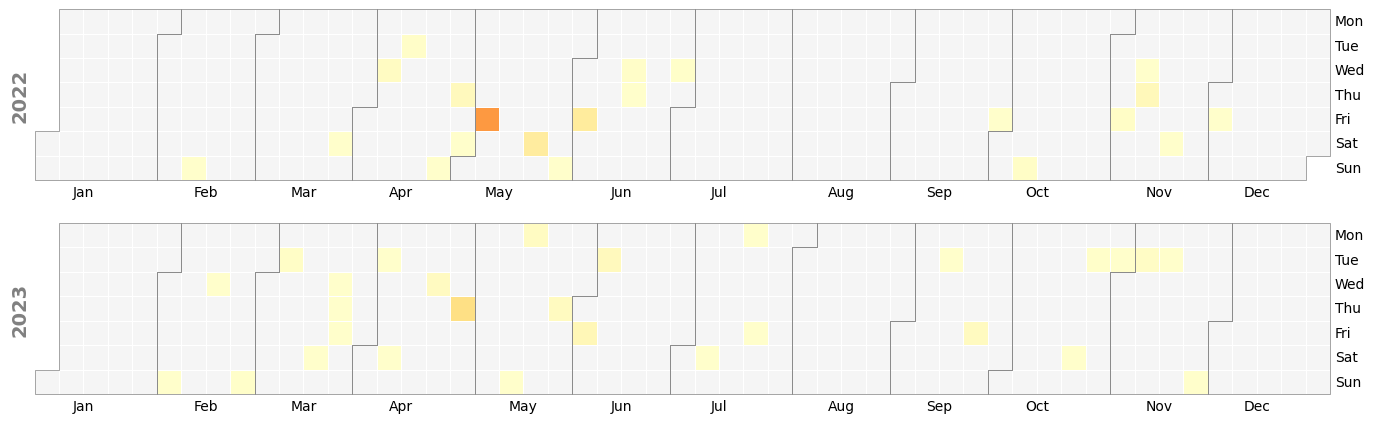

In [39]:
plot_extreme_weather_calendar(
    day_total_all_eas_norm,
    event_col='PWL',
    cmap='YlOrRd',
    
    # Cell border styling
    linewidth=0.5, 
    linecolor='white',

    # Missing-day color
    fillcolor='whitesmoke',
    
    start_august=False,
    title='', 
    show_colorbar=False,
    # save_path = PLOTS_DIR / 'PWL_calendar_plot.png'
)

### Summary Stats 

In [40]:
import pandas as pd

GHANA_SEASONS = {
    12: "Dry",  1: "Dry",  2: "Dry",  3: "Dry",
     4: "Major Rainy",  5: "Major Rainy",  6: "Major Rainy",  7: "Major Rainy",
     8: "Transition",
     9: "Minor Rainy", 10: "Minor Rainy", 11: "Minor Rainy",
}

# Ordered for display
SEASON_ORDER = ["Dry", "Major Rainy", "Transition", "Minor Rainy"]

def summarise_event_days(
    df: pd.DataFrame,
    event: str,
    threshold: float = 0.0,
    season_map: dict = GHANA_SEASONS,
    date_col: str = "Date",
) -> pd.DataFrame:
    """
    Summarise days per season where ≥ threshold % of EAs experienced `event`.

    Parameters
    ----------
    df        : day_total_all_eas_norm (Date + event-proportion columns)
    event     : column name, e.g. 'T', 'PW', 'PWL'
    threshold : minimum % of EAs required (default 0 → any nonzero day)
    season_map: month → season label mapping (defaults to GHANA_SEASONS)
    date_col  : name of the date column

    Returns
    -------
    DataFrame: Season | n_days | pct_of_season_days | mean_ea_pct | median_ea_pct | max_ea_pct
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["_season"] = df[date_col].dt.month.map(season_map)

    season_totals = df.groupby("_season")[date_col].count().rename("total_days")

    summary = (
        df[df[event] >= threshold]
        .groupby("_season")[event]
        .agg(
            n_days="count",
            mean_ea_pct="mean",
            # median_ea_pct="median",
            # max_ea_pct="max",
        )
        .join(season_totals)
        .assign(pct_of_season_days=lambda x: 100 * x["n_days"] / x["total_days"])
        .drop(columns="total_days")
        .reindex(SEASON_ORDER)          # consistent row order
        .reset_index()
        .rename(columns={"_season": "Season"})
    )

    return summary.round(2)

In [41]:
pct_one_ea = (1/214)*100

In [42]:
# summarise_event_days(day_total_all_eas_norm, event='T', threshold=pct_one_ea)

In [43]:
# summarise_event_days(day_total_all_eas_norm, event='PW', threshold=pct_one_ea)

In [44]:
# summarise_event_days(day_total_all_eas_norm, event='WL', threshold=pct_one_ea)

In [45]:
# summarise_event_days(day_total_all_eas_norm, event='PL', threshold=pct_one_ea)

In [46]:
# summarise_event_days(day_total_all_eas_norm, event='PWL', threshold=pct_one_ea)